In [1]:
import h5py

with h5py.File("pp_output_test_background.h5", "r") as f:
    print(list(f.keys()))

['jets', 'tracks']


In [2]:
import h5py

with h5py.File("pp_output_test_signal.h5", "r") as f:
    print(list(f.keys()))

['jets', 'tracks', 'truth_dark_pions', 'truth_stable_non_geant']


In [6]:
with h5py.File("pp_output_test_signal.h5", "r") as f:
    dati = f["jets"][:]
    print(dati)

[(391629.7 ,  1.1941876 , 711230.2 ,  88660.37 , 1.        , 0.96617365,  35867.605, 0.22978075, 1.7265829, 0.18716449, 0.11527643, 0.06391562, 0.04038873, 0.61590976, 0.5544552 , 399034.94, 2.1190834e+10, 2.5858231e+14, 9.23753114e+17,  31769.209, 21134.56  , 12632.141 ,  0.5289717 , 1, 1, 1., 20001, 30.499998, 30.499998, 18, 0)
 (379995.62, -1.4500756 , 855664.4 ,  42501.516, 0.98242676, 0.93051755,   9159.465, 0.05288789, 0.880045 , 0.11229596, 0.02455441, 0.00712643, 0.00108699, 0.21865799, 0.29023007, 335077.2 , 6.7474719e+09, 7.1861047e+12, 6.05362151e+14,  27626.477,  5993.5244,  2023.6761, -0.23856393, 1, 1, 1., 20001, 30.499998, 30.499998, 18, 0)
 (432672.94, -0.24039702, 455703.16,  97111.79 , 1.        , 1.0122575 ,  30430.383, 0.30223358, 4.2847524, 0.07669149, 0.05152261, 0.03247973, 0.02175574, 0.67181647, 0.6303977 , 415820.3 , 1.2196308e+10, 1.0811694e+14, 3.47797896e+17,  18813.732,  9223.026 ,  4755.7085,  0.6472624 , 1, 1, 1., 20023, 31.499998, 31.499998, 20, 0)
 ...

In [10]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
files = [
    "pp_output_test_background.h5",
    "pp_output_test_signal.h5",
    "pp_output_val.h5"
]

In [5]:
def print_h5_structure(file_path):
    print(f"\n===== {file_path} =====")
    
    with h5py.File(file_path, "r") as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"[DATASET] {name}")
                print(f"  shape: {obj.shape}")
                print(f"  dtype: {obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"[GROUP]   {name}")
        
        f.visititems(visitor)

for file in files:
    print_h5_structure(file)


===== pp_output_test_background.h5 =====
[DATASET] jets
  shape: (1000000,)
  dtype: [('pt', '<f4'), ('eta', '<f4'), ('energy', '<f4'), ('mass', '<f4'), ('salt_pdisp', '<f4'), ('displacedPtFraction', '<f4'), ('Qw_clusterSoftDrop', '<f4'), ('C2_clusterSoftDrop', '<f4'), ('D2_clusterSoftDrop', '<f4'), ('Tau1_clusterSoftDrop', '<f4'), ('Tau2_clusterSoftDrop', '<f4'), ('Tau3_clusterSoftDrop', '<f4'), ('Tau4_clusterSoftDrop', '<f4'), ('Tau21_clusterSoftDrop', '<f4'), ('Tau32_clusterSoftDrop', '<f4'), ('ECF1_clusterSoftDrop', '<f4'), ('ECF2_clusterSoftDrop', '<f4'), ('ECF3_clusterSoftDrop', '<f4'), ('ECF4_clusterSoftDrop', '<f4'), ('Split12_clusterSoftDrop', '<f4'), ('Split23_clusterSoftDrop', '<f4'), ('Split34_clusterSoftDrop', '<f4'), ('timing_clusterSoftDrop', '<f4'), ('isTagged', '<i4'), ('isDisplaced', '<i4'), ('mcEventWeight', '<f4'), ('eventNumber', '<i8'), ('averageInteractionsPerCrossing', '<f4'), ('actualInteractionsPerCrossing', '<f4'), ('nPrimaryVertices', '<i4'), ('isRun3', 'i1

In [6]:
def jets_to_dataframe(file_path, n=5):
    with h5py.File(file_path, "r") as f:
        jets = f["jets"][:n]
        df = pd.DataFrame({name: jets[name] for name in jets.dtype.names})
    return df

df_jets = jets_to_dataframe("pp_output_test_background.h5", n=10)
df_jets

,pt,eta,energy,mass,salt_pdisp,displacedPtFraction,Qw_clusterSoftDrop,C2_clusterSoftDrop,D2_clusterSoftDrop,Tau1_clusterSoftDrop,...,timing_clusterSoftDrop,isTagged,isDisplaced,mcEventWeight,eventNumber,averageInteractionsPerCrossing,actualInteractionsPerCrossing,nPrimaryVertices,isRun3,flavour_label
0,3.746139e+06,0.329898,3.954103e+06,133555.062500,0.000010,0.0,34464.519531,0.038843,3.376547,0.012543,...,0.170181,0,0,1.079950e-13,14337879,95.500000,95.500000,53,1,0
1,2.148846e+05,1.037657,3.481287e+05,68457.914062,0.044368,0.0,20103.087891,0.194084,1.100211,0.276119,...,0.237933,0,0,2.987821e-13,9101519,58.500000,58.500000,34,0,0
2,3.372936e+05,0.600756,4.063434e+05,71449.914062,0.050128,0.0,6411.085938,0.043381,2.156171,0.026027,...,0.367847,0,0,1.309806e-10,26732669,54.500000,54.500000,27,1,0
3,2.846625e+05,1.297154,5.644053e+05,72946.890625,0.037121,0.0,72686.679688,0.452365,2.360612,0.241766,...,0.231195,0,0,2.191900e-06,109095199,69.500000,69.500000,34,1,0
4,4.469554e+06,-0.130966,4.509488e+06,118103.921875,0.000003,0.0,0.000000,0.000000,0.000000,0.002925,...,0.286322,0,0,4.933394e-14,29224069,56.500004,56.500004,30,1,0
5,1.311200e+06,-0.926818,1.927962e+06,215870.062500,0.001651,0.0,83202.320312,0.234725,4.029923,0.070772,...,0.112259,0,0,3.024672e-09,35554109,66.500000,66.500000,38,1,0
6,9.049230e+05,-0.676179,1.120546e+06,40882.750000,0.001087,0.0,6122.110352,0.035347,2.673723,0.015513,...,0.202123,0,0,1.685254e-08,12644449,46.500000,46.500000,27,0,0
7,7.815281e+05,-0.816054,1.064049e+06,126343.976562,0.002761,0.0,16999.714844,0.063357,2.234837,0.035368,...,0.039216,0,0,1.407162e-07,48010679,55.500000,55.500000,33,0,0
8,2.160369e+05,-0.782137,2.864295e+05,22378.388672,0.005441,0.0,10495.799805,0.093197,1.766989,0.078186,...,0.598953,0,0,2.995347e-06,43463659,56.500000,56.500000,37,0,0
9,1.726221e+06,1.170150,3.053163e+06,155617.593750,0.000242,0.0,45034.386719,0.060523,2.074065,0.036547,...,0.214614,0,0,9.464738e-10,19845339,63.500000,63.500000,37,1,0


In [7]:
def tracks_of_one_jet(file_path, jet_index=0):
    with h5py.File(file_path, "r") as f:
        tracks = f["tracks"][jet_index]
        df = pd.DataFrame({name: tracks[name] for name in tracks.dtype.names})
    return df

df_tracks = tracks_of_one_jet("pp_output_test_background.h5", jet_index=0)
df_tracks.head(20)

,numberOfInnermostPixelLayerHits,numberOfPixelHits,numberOfPixelHoles,numberOfPixelSharedHits,numberOfSCTHits,numberOfSCTHoles,numberOfSCTSharedHits,truthOriginLabel,truthVertexIndex,VSIVertexIndex,...,dphi,dr,ptfrac,z0RelativeToBeamspotUncertainty,IP3D_signed_d0,IP2D_signed_d0,IP3D_signed_z0,IP3D_signed_d0_significance,IP3D_signed_z0_significance,valid
0,1,4,0,0,8,0,2,2,0,-2,...,-0.005939,0.006584,0.201050,0.100342,-0.024323,-0.024323,-7.523438,-1.014648,-0.184326,True
1,1,4,0,1,8,0,2,0,-2,-2,...,-0.016373,0.016891,0.182617,0.113708,-0.511719,0.511719,-7.386719,-21.015625,-0.180908,True
2,1,4,0,0,8,0,0,2,0,-2,...,-0.009842,0.010391,0.116699,0.120972,-0.154663,0.154663,-7.320312,-5.796875,-0.179443,True
3,1,4,0,0,8,0,2,2,0,-2,...,-0.009491,0.013847,0.025482,0.121399,-0.122498,0.122498,-7.074219,-4.300781,-0.172974,True
4,0,1,0,0,8,0,0,2,0,-2,...,-0.003222,0.003248,0.012566,0.134766,-0.316650,-0.316650,-7.617188,-7.492188,-0.186890,True
5,0,1,1,0,8,0,0,0,-2,-2,...,-0.201050,0.212036,0.009735,0.101135,55.000000,55.000000,118.375000,2023.000000,2.847656,True
6,0,1,0,0,7,0,0,0,-2,-2,...,0.512695,0.995117,0.008995,0.177368,-94.125000,-94.125000,-11.460938,-2007.000000,-0.475830,True
7,0,2,0,0,9,0,0,2,0,-2,...,-0.051758,0.052612,0.005844,0.110596,0.020767,-0.020767,7.343750,1.029297,0.180786,True
8,0,0,0,0,8,0,0,0,-2,-2,...,-0.347412,0.886719,0.005058,1.803711,96.000000,96.000000,125.312500,264.500000,3.263672,True
9,0,0,0,0,8,0,0,0,-2,-2,...,0.199707,0.619629,0.004154,5.613281,-147.250000,-147.250000,-110.562500,-182.500000,-2.630859,True


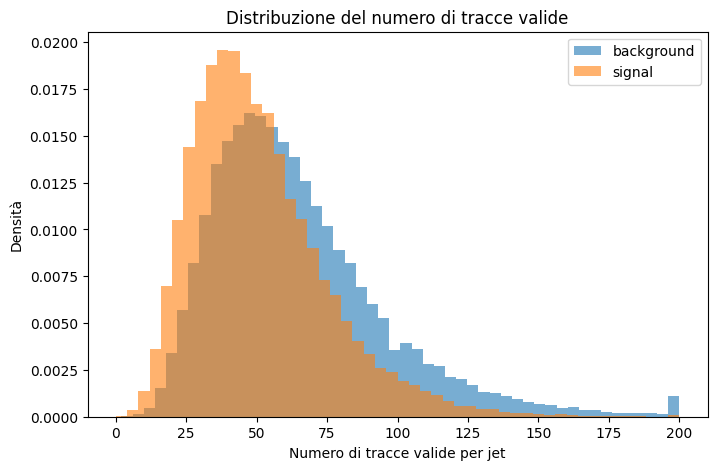

In [11]:
def valid_track_counts(file_path, max_jets=100_000):
    with h5py.File(file_path, "r") as f:
        tracks = f["tracks"][:max_jets]
        valid = tracks["valid"]
        counts = valid.sum(axis=1)
    return counts

counts_bg = valid_track_counts("pp_output_test_background.h5", max_jets=100_000)
counts_sig = valid_track_counts("pp_output_test_signal.h5", max_jets=61_966)

plt.figure(figsize=(8, 5))
plt.hist(counts_bg, bins=50, alpha=0.6, label="background", density=True)
plt.hist(counts_sig, bins=50, alpha=0.6, label="signal", density=True)
plt.xlabel("Numero di tracce valide per jet")
plt.ylabel("Densità")
plt.legend()
plt.title("Distribuzione del numero di tracce valide")
plt.show()

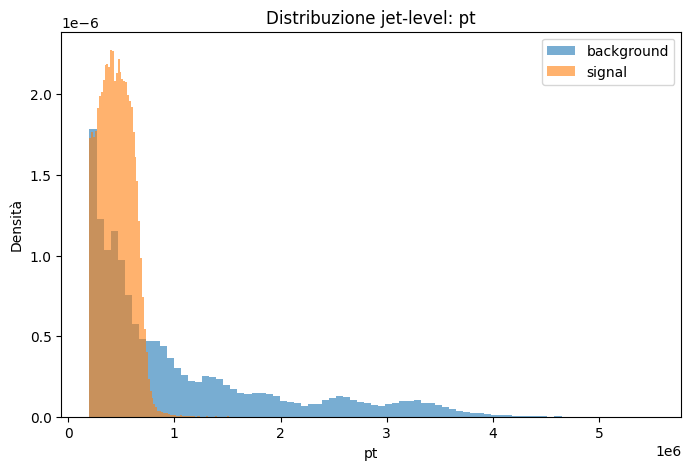

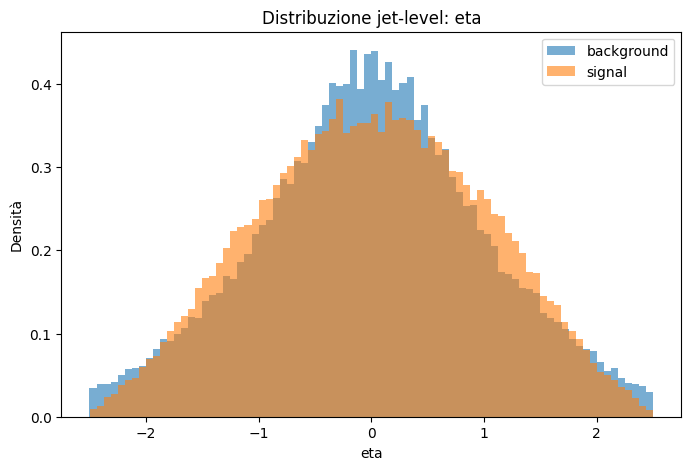

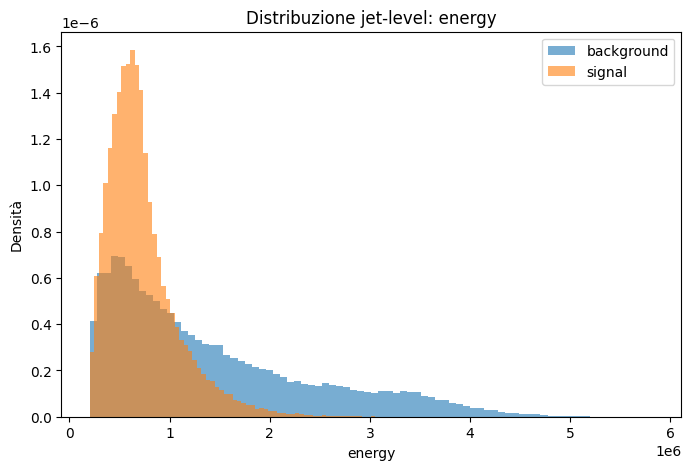

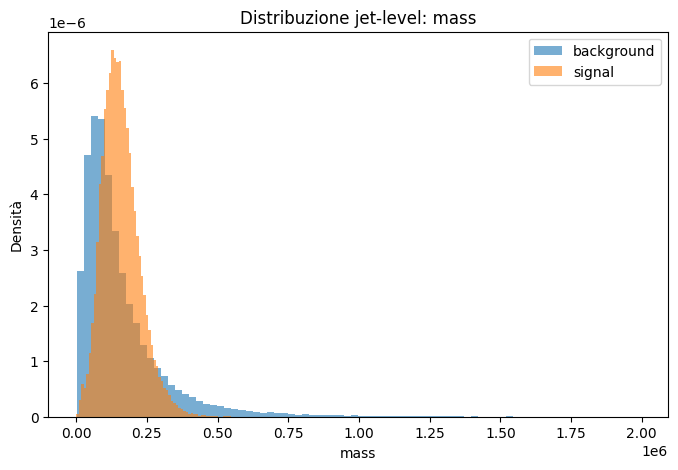

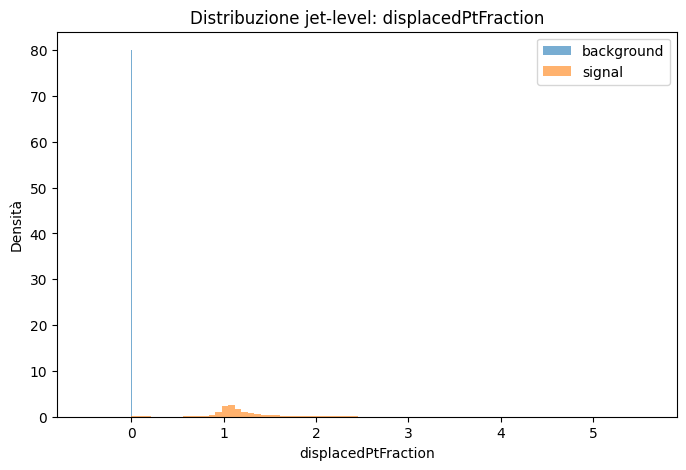

In [12]:
def load_jet_feature(file_path, feature, max_jets=100_000):
    with h5py.File(file_path, "r") as f:
        return f["jets"][feature][:max_jets]

jet_features = ["pt", "eta", "energy", "mass", "displacedPtFraction"]

for feat in jet_features:
    bg = load_jet_feature("pp_output_test_background.h5", feat)
    sig = load_jet_feature("pp_output_test_signal.h5", feat)

    plt.figure(figsize=(8, 5))
    plt.hist(bg, bins=80, alpha=0.6, label="background", density=True)
    plt.hist(sig, bins=80, alpha=0.6, label="signal", density=True)
    plt.xlabel(feat)
    plt.ylabel("Densità")
    plt.legend()
    plt.title(f"Distribuzione jet-level: {feat}")
    plt.show()

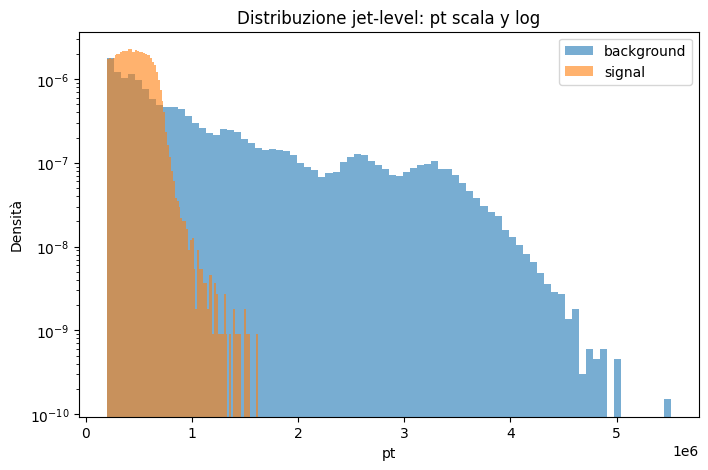

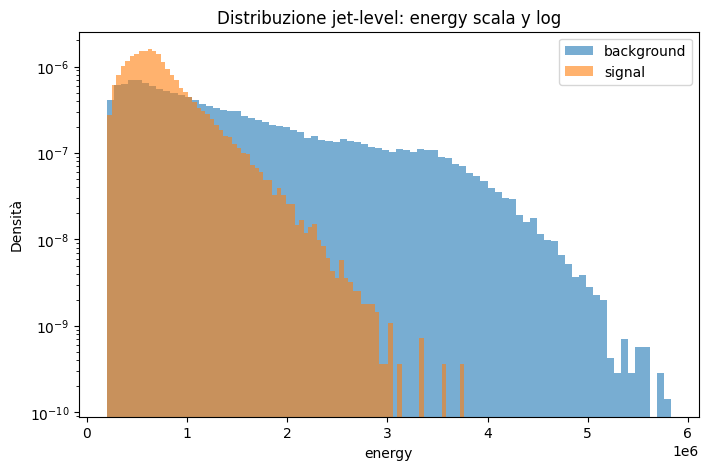

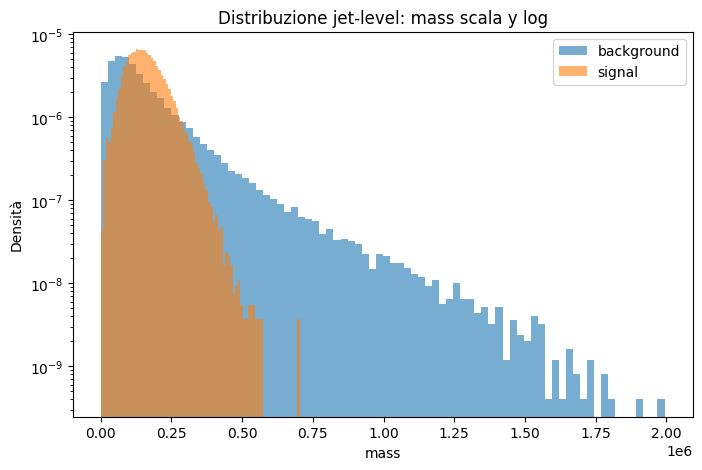

In [13]:
for feat in ["pt", "energy", "mass"]:
    bg = load_jet_feature("pp_output_test_background.h5", feat)
    sig = load_jet_feature("pp_output_test_signal.h5", feat)

    plt.figure(figsize=(8, 5))
    plt.hist(bg, bins=80, alpha=0.6, label="background", density=True)
    plt.hist(sig, bins=80, alpha=0.6, label="signal", density=True)
    plt.xlabel(feat)
    plt.ylabel("Densità")
    plt.yscale("log")
    plt.legend()
    plt.title(f"Distribuzione jet-level: {feat} scala y log")
    plt.show()

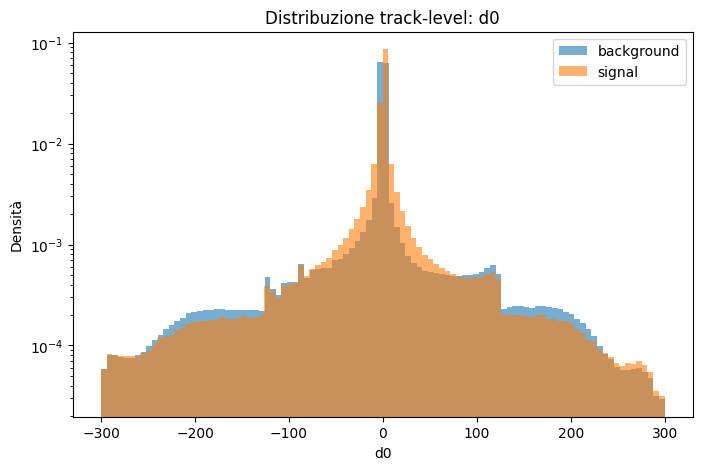

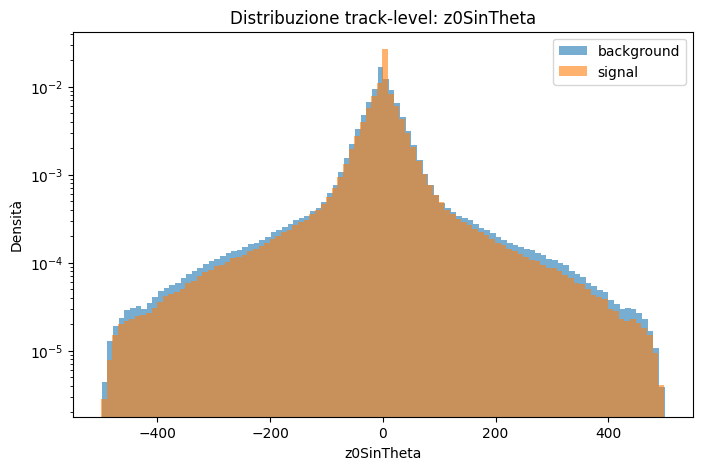

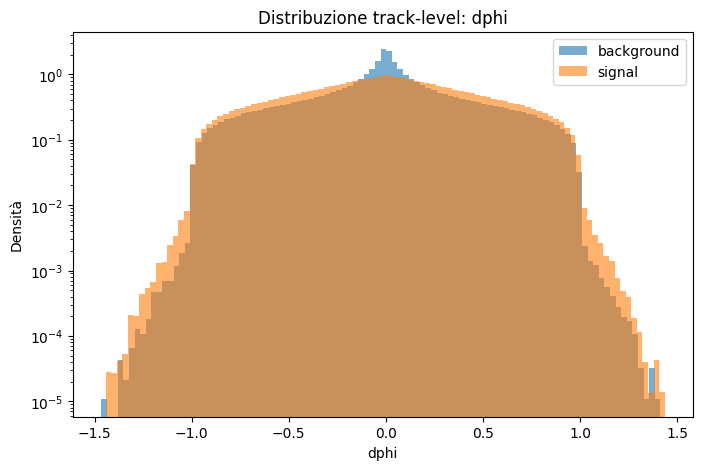

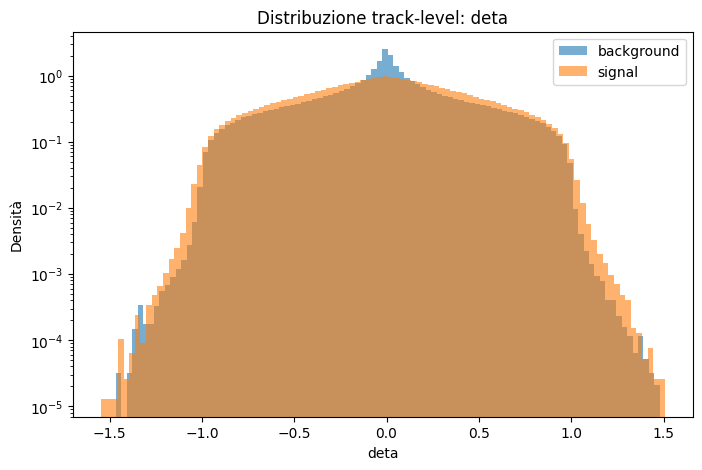

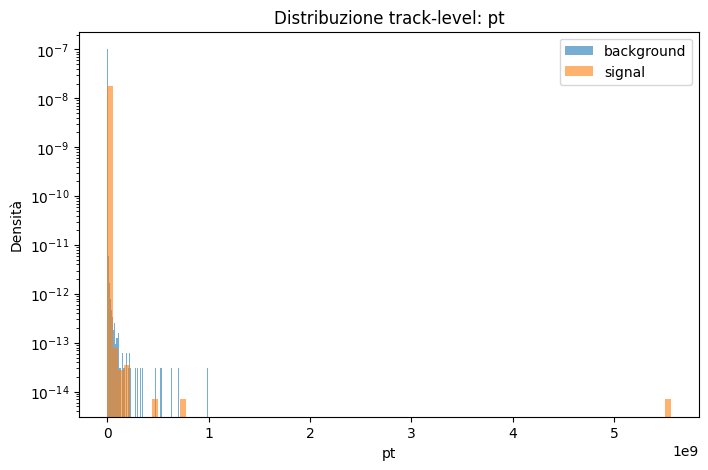

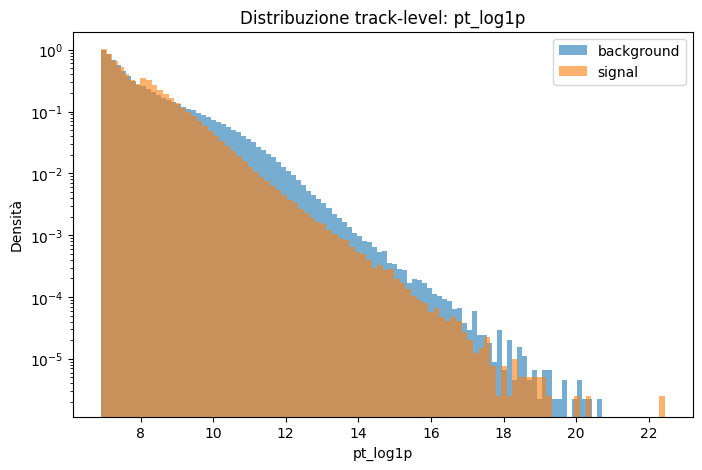

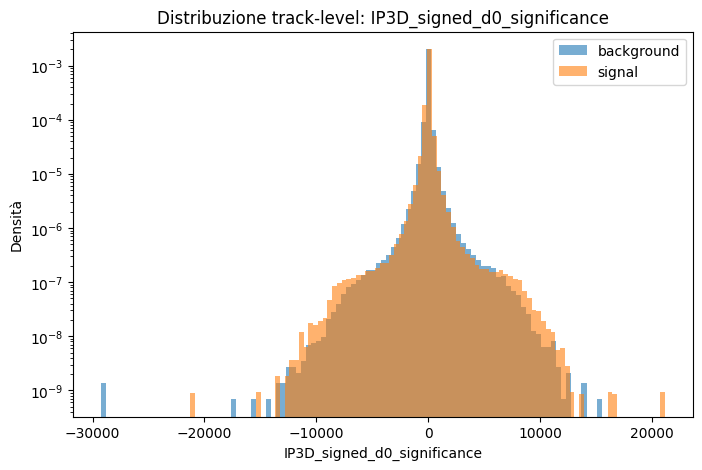

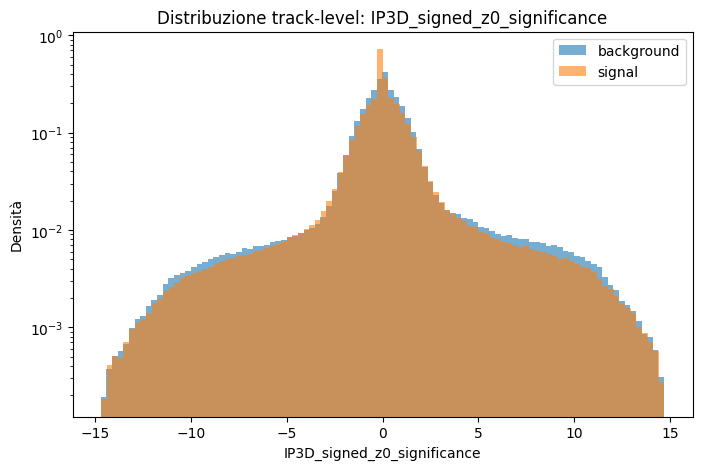

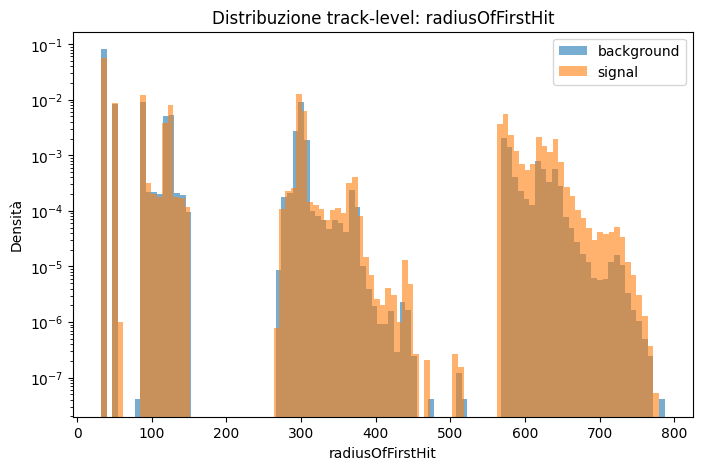

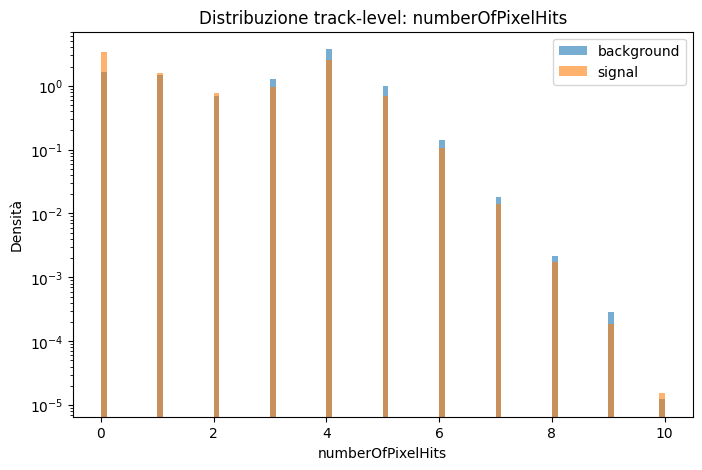

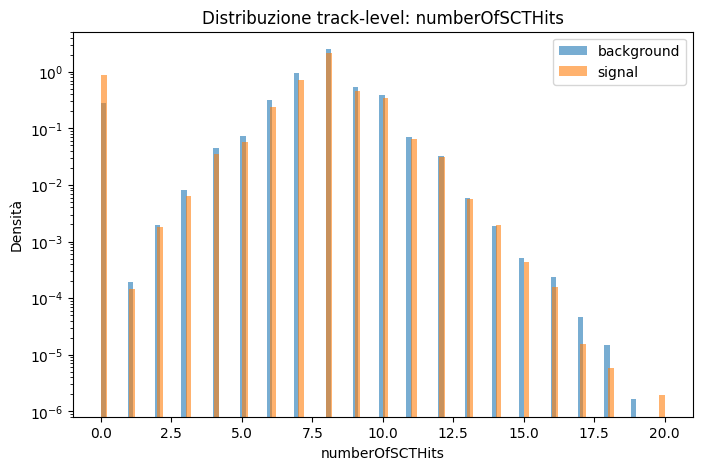

In [14]:
def load_track_feature_valid(file_path, feature, max_jets=50_000):
    with h5py.File(file_path, "r") as f:
        tracks = f["tracks"][:max_jets]
        valid = tracks["valid"]
        values = tracks[feature][valid]
    return values

track_features = [
    "d0",
    "z0SinTheta",
    "dphi",
    "deta",
    "pt",
    "pt_log1p",
    "IP3D_signed_d0_significance",
    "IP3D_signed_z0_significance",
    "radiusOfFirstHit",
    "numberOfPixelHits",
    "numberOfSCTHits"
]

for feat in track_features:
    bg = load_track_feature_valid("pp_output_test_background.h5", feat)
    sig = load_track_feature_valid("pp_output_test_signal.h5", feat)

    plt.figure(figsize=(8, 5))
    plt.hist(bg, bins=100, alpha=0.6, label="background", density=True)
    plt.hist(sig, bins=100, alpha=0.6, label="signal", density=True)
    plt.xlabel(feat)
    plt.ylabel("Densità")
    plt.yscale("log")
    plt.legend()
    plt.title(f"Distribuzione track-level: {feat}")
    plt.show()

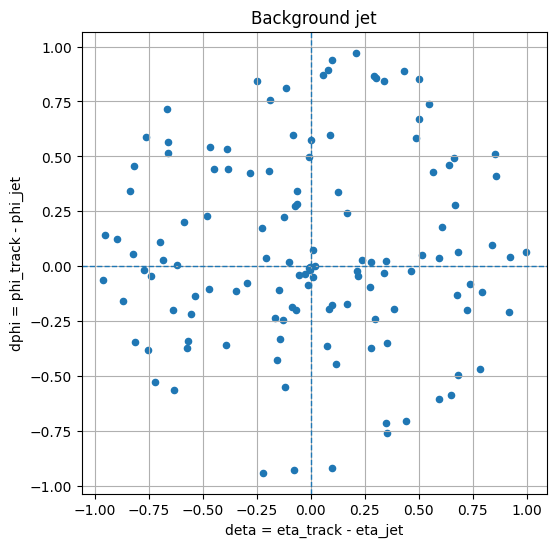

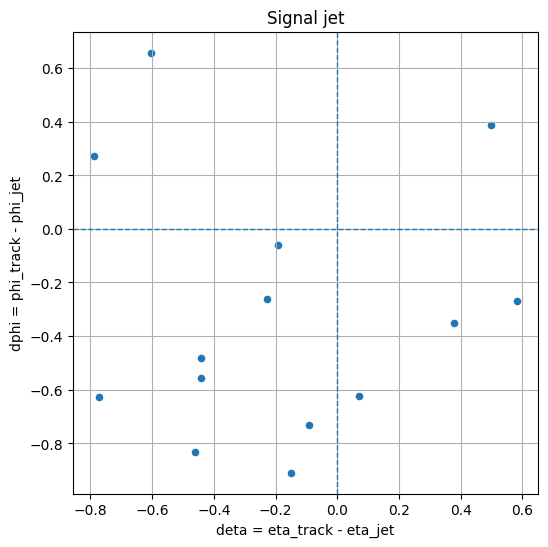

In [15]:
def plot_jet_tracks_eta_phi(file_path, jet_index=0, title=None):
    df = tracks_of_one_jet(file_path, jet_index)
    df = df[df["valid"] == True]

    plt.figure(figsize=(6, 6))
    plt.scatter(df["deta"], df["dphi"], s=20)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("deta = eta_track - eta_jet")
    plt.ylabel("dphi = phi_track - phi_jet")
    plt.title(title or f"Jet {jet_index}")
    plt.grid(True)
    plt.show()

plot_jet_tracks_eta_phi("pp_output_test_background.h5", jet_index=0, title="Background jet")
plot_jet_tracks_eta_phi("pp_output_test_signal.h5", jet_index=0, title="Signal jet")

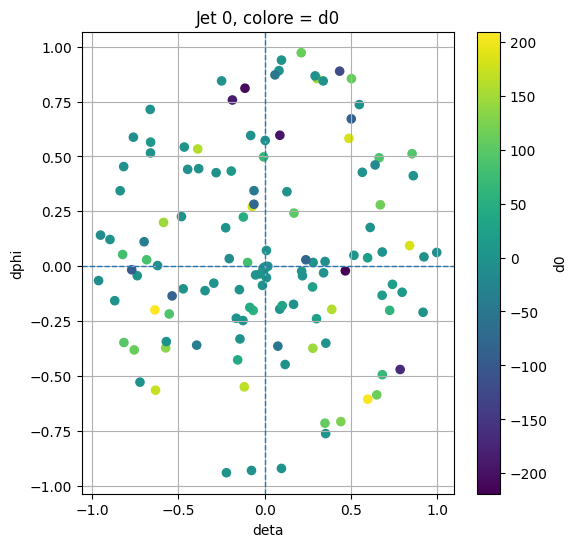

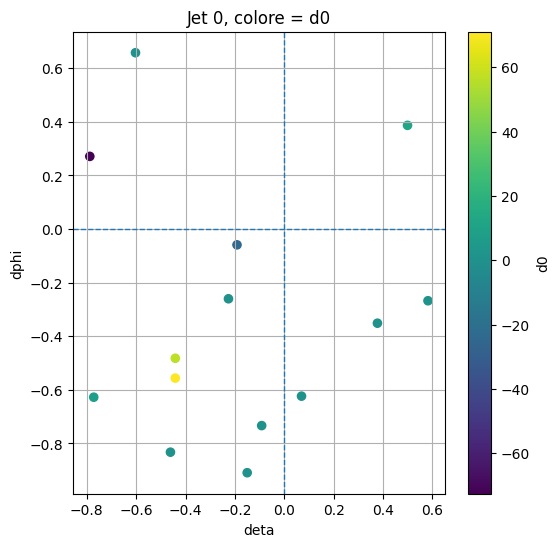

In [16]:
def plot_jet_tracks_colored(file_path, jet_index=0, color_feature="d0"):
    df = tracks_of_one_jet(file_path, jet_index)
    df = df[df["valid"] == True]

    plt.figure(figsize=(6, 6))
    sc = plt.scatter(
        df["deta"],
        df["dphi"],
        c=df[color_feature],
        s=35
    )
    plt.colorbar(sc, label=color_feature)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("deta")
    plt.ylabel("dphi")
    plt.title(f"Jet {jet_index}, colore = {color_feature}")
    plt.grid(True)
    plt.show()

plot_jet_tracks_colored("pp_output_test_background.h5", jet_index=0, color_feature="d0")
plot_jet_tracks_colored("pp_output_test_signal.h5", jet_index=0, color_feature="d0")

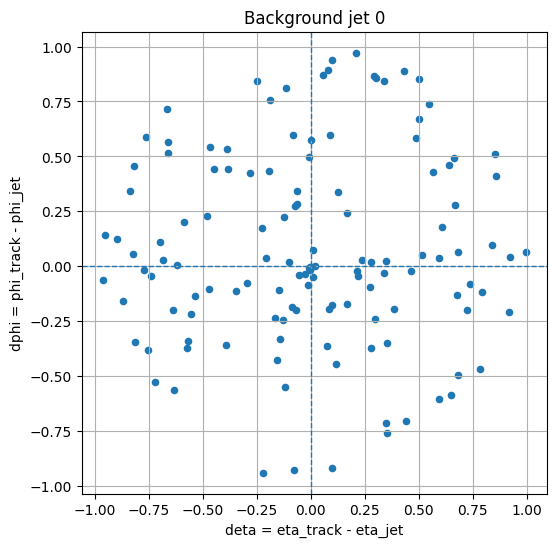

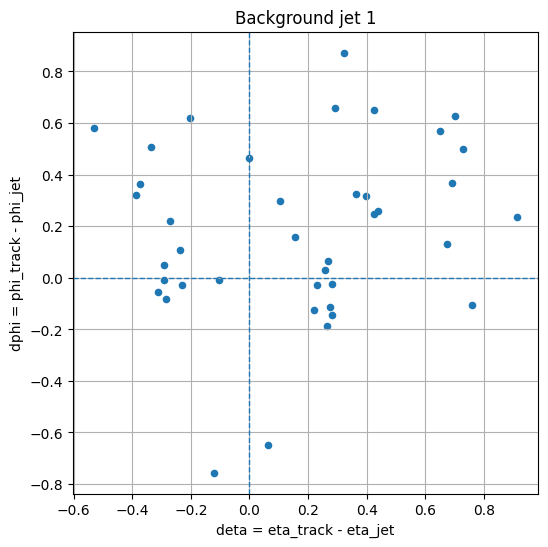

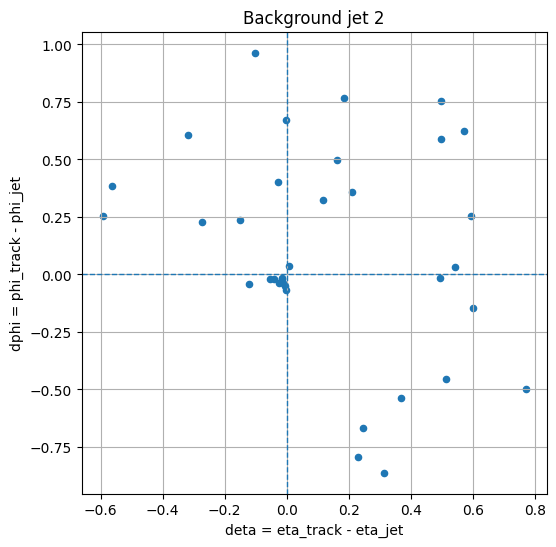

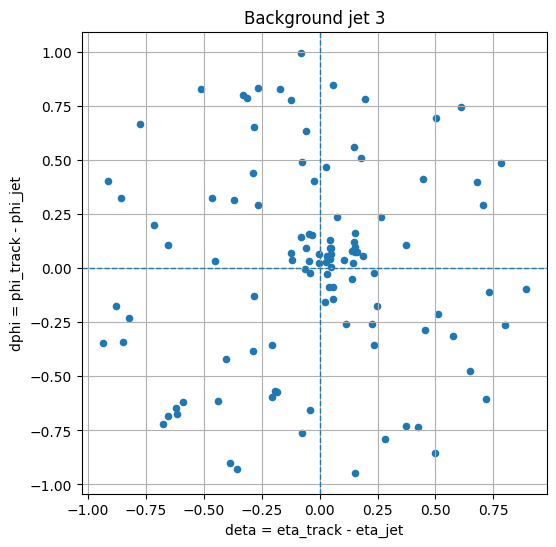

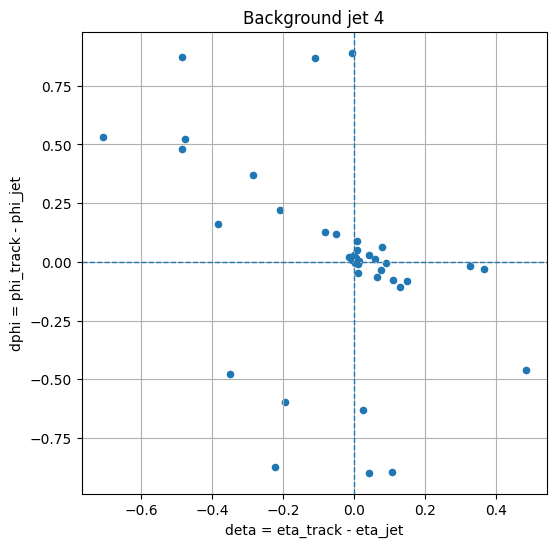

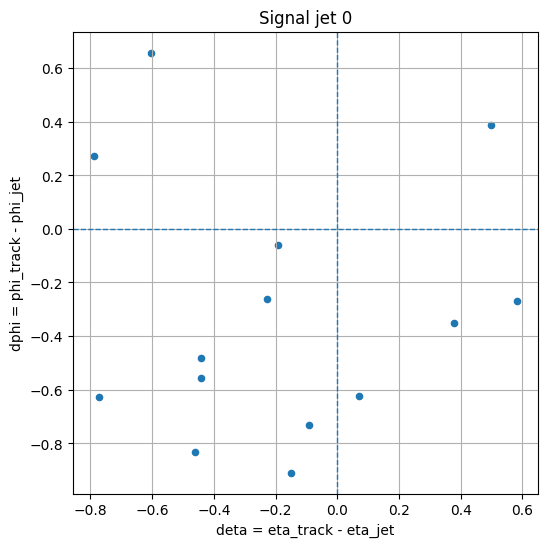

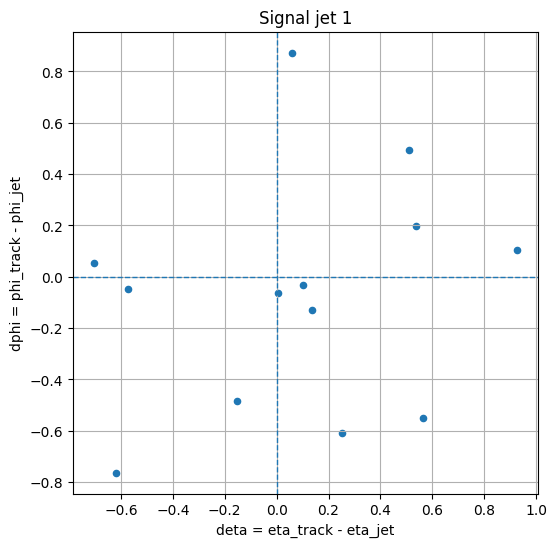

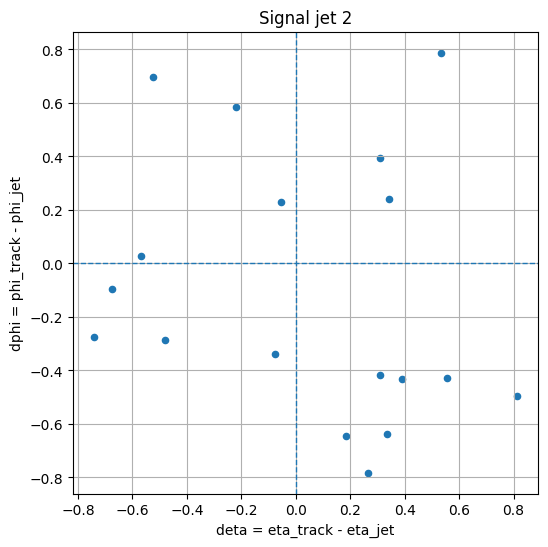

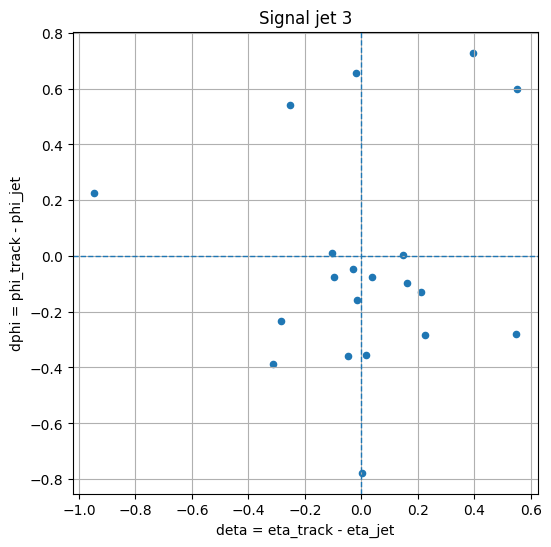

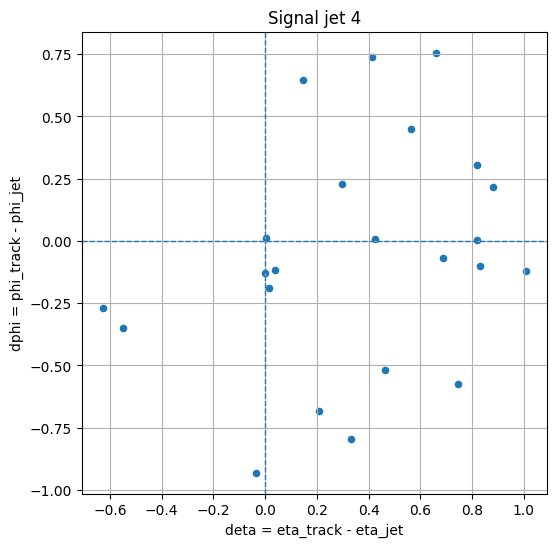

In [17]:
def plot_many_jets(file_path, jet_indices, title_prefix):
    for idx in jet_indices:
        plot_jet_tracks_eta_phi(
            file_path,
            jet_index=idx,
            title=f"{title_prefix} jet {idx}"
        )

plot_many_jets("pp_output_test_background.h5", [0, 1, 2, 3, 4], "Background")
plot_many_jets("pp_output_test_signal.h5", [0, 1, 2, 3, 4], "Signal")

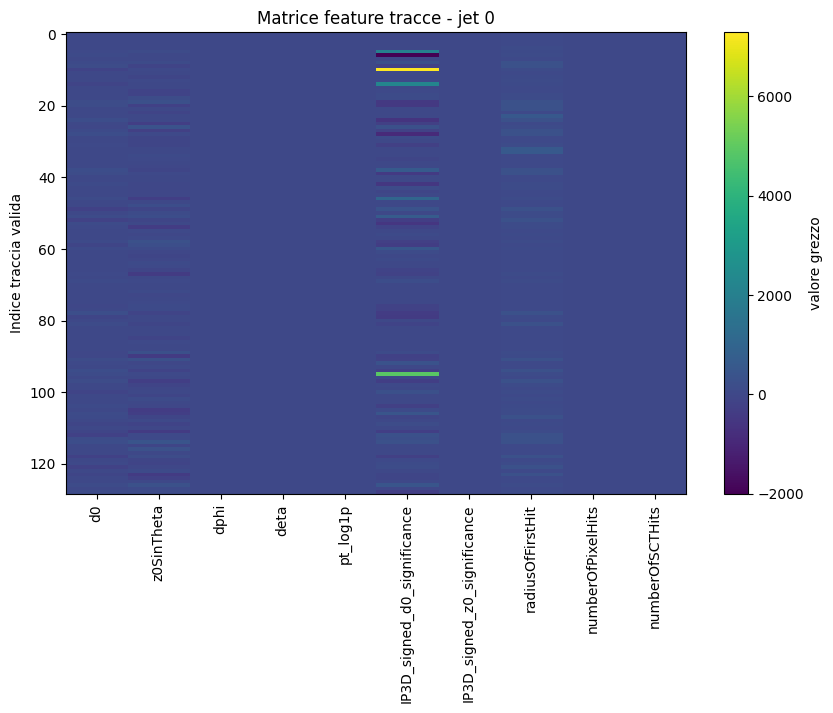

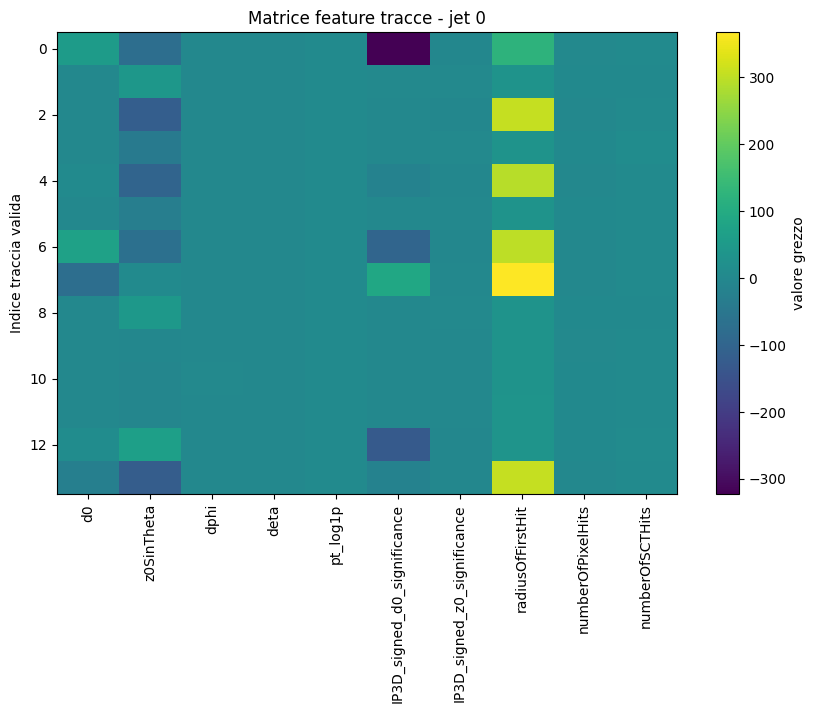

In [18]:
def plot_track_feature_matrix(file_path, jet_index=0, features=None):
    if features is None:
        features = [
            "d0",
            "z0SinTheta",
            "dphi",
            "deta",
            "pt_log1p",
            "IP3D_signed_d0_significance",
            "IP3D_signed_z0_significance",
            "radiusOfFirstHit",
            "numberOfPixelHits",
            "numberOfSCTHits"
        ]

    df = tracks_of_one_jet(file_path, jet_index)
    df = df[df["valid"] == True]

    matrix = df[features].to_numpy()

    plt.figure(figsize=(10, 6))
    plt.imshow(matrix, aspect="auto")
    plt.colorbar(label="valore grezzo")
    plt.xticks(range(len(features)), features, rotation=90)
    plt.ylabel("Indice traccia valida")
    plt.title(f"Matrice feature tracce - jet {jet_index}")
    plt.show()

plot_track_feature_matrix("pp_output_test_background.h5", jet_index=0)
plot_track_feature_matrix("pp_output_test_signal.h5", jet_index=0)